In [21]:
#Step 1: Importing the necessary libraries for historical data
import yfinance
import pandas as pd

#Step 2: Fetching historical data for a specific stock (e.g., Apple Inc.)
ticker = ["AAPL", "AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","AVGO","AMD","ORCL",
        "CRM","ADBE","INTC","QCOM","CSCO","TXN","NFLX","AMAT","MU","PANW",
        "NOW","INTU","UBER","SNOW","SHOP", "PYPL","IBM","DELL","SMCI"] # will change this later for now these should be ok to test.
benchmark = ["SPY"]
alltickers = ticker + [benchmark]
start_date = "2020-01-01"
end_date = None  # Fetch data up to the current date
historical_data = yfinance.download(ticker, start=start_date, end=end_date, progress=False) #Stocks that are going to be used for backtesting against the S&P 500 index (SPY) which is a commonly used benchmark for the overall stock market performance.
benchmark_data = yfinance.download(benchmark, start=start_date, end=end_date, progress=False)
print(historical_data)




Price            Close                                                  \
Ticker            AAPL        ADBE        AMAT         AMD        AMZN   
Date                                                                     
2020-01-02   72.400520  334.429993   58.772671   49.099998   94.900497   
2020-01-03   71.696648  331.809998   57.837223   48.599998   93.748497   
2020-01-06   72.267952  333.709991   56.589954   48.389999   95.143997   
2020-01-07   71.928062  333.390015   58.224628   48.250000   95.343002   
2020-01-08   73.085098  337.869995   58.186832   47.830002   94.598503   
...                ...         ...         ...         ...         ...   
2026-02-09  274.619995  266.899994  330.570007  216.000000  208.720001   
2026-02-10  273.679993  264.670013  329.070007  213.570007  206.960007   
2026-02-11  275.500000  257.160004  339.880005  213.580002  204.080002   
2026-02-12  261.730011  262.500000  328.390015  205.940002  199.600006   
2026-02-13  255.779999  263.970001  35

Text(0, 0.5, 'Closing Price (USD)')

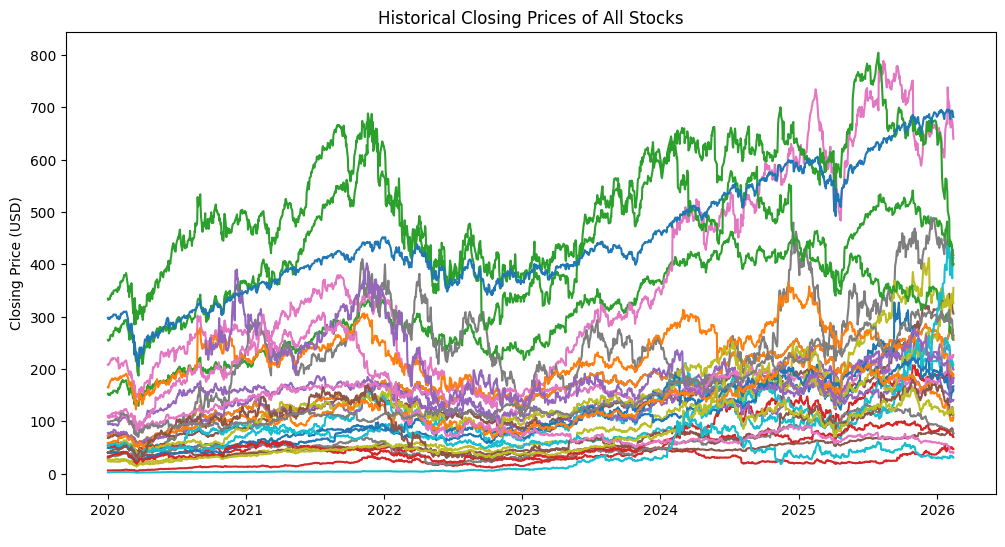

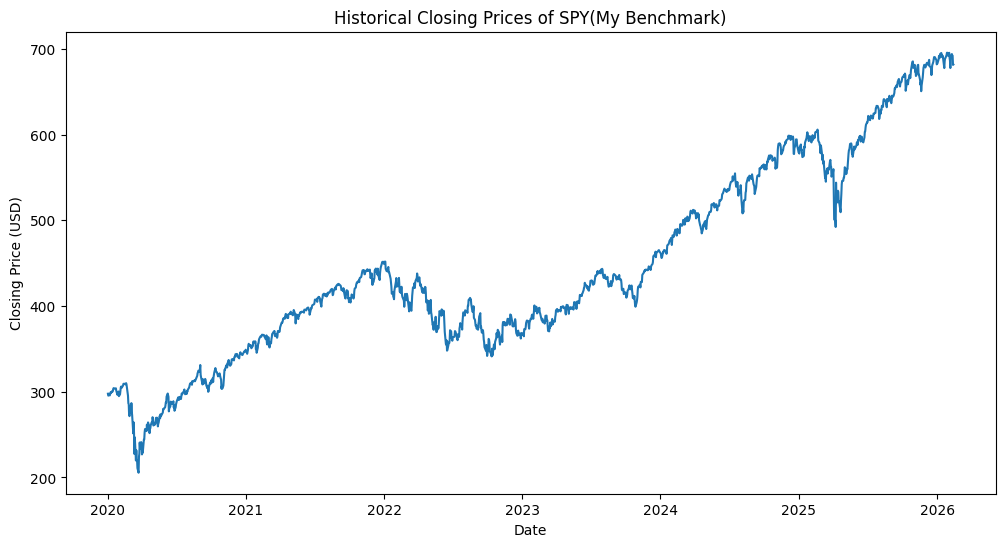

In [22]:
#Step 3: Compiling Historical data into a visual model for analysis.
import yfinance as yf
import matplotlib.pyplot as plt
# Plotting the closing price of the stocks over time
plt.figure(figsize=(12,6))
for stock in alltickers:
    data = yf.download(stock, start=start_date, end=end_date, progress=False)
    plt.plot(data['Close'], label=stock)
plt.title('Historical Closing Prices of All Stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.figure(figsize=(12,6)) # Plotting the closing price of the benchmark (SPY) over time
for stock in benchmark:
    data = yf.download(stock, start=start_date, end=end_date, progress=False)
    plt.plot(data['Close'], label=stock)
plt.title('Historical Closing Prices of SPY(My Benchmark)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

In [23]:
# Step 4: Analyzing the sharpe ratio of SPY between 2015 and 2025 to understand the risk-adjusted return of the benchmark during that period.
import numpy as np
import pandas as pd
spy_data = yf.download('SPY', start='2015-01-01', end='2025-12-31', progress=False)
# Calculating daily returns, avg and std
spy_data['Daily Return'] = spy_data['Close'].pct_change()
average_daily_return = spy_data['Daily Return'].mean()
std_daily_return = spy_data['Daily Return'].std()
# Assuming a risk-free rate of 4% using the US 10 year Treasury bond yield as a benchmark
daily_returns = spy_data['Daily Return'].dropna()
annualized_return = daily_returns.mean() * 252
annualized_vol = daily_returns.std() * np.sqrt(252)
risk_free_rate = 0.04
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
print("Sharpe ratio of SPY between 2015 and 2025:", sharpe_ratio)

Sharpe ratio of SPY between 2015 and 2025: 0.5783568415012601


In [ ]:
#Step 5: Analyzing the volatility of certain stocks (e.g., AAPL, MSFT, TSLA) compared to the benchmark (SPY) to understand the risk associated with these stocks relative to the overall market.
# will be using mean reversion to analyze the volatility of the stocks compared to the benchmark.
import yfinance as yf
import numpy as np
import pandas as pd

aapl = yf.download("AAPL", start="2015-01-01", end="2025-12-31", progress=False)
msft = yf.download("MSFT", start="2015-01-01", end="2025-12-31", progress=False)
tsla = yf.download("TSLA", start="2015-01-01", end="2025-12-31", progress=False)
spy = yf.download("SPY", start="2015-01-01", end="2025-12-31", progress=False)
# Calculating daily returns
aapl['Daily Return'] = aapl['Close'].pct_change()
msft['Daily Return'] = msft['Close'].pct_change()
tsla['Daily Return'] = tsla['Close'].pct_change()
aapl['MA50'] = aapl['Close'].rolling(window=50).mean()
aapl['MA200'] = aapl['Close'].rolling(window=200).mean()
msft['MA50'] = msft['Close'].rolling(window=50).mean()
msft['MA200'] = msft['Close'].rolling(window=200).mean()
tsla['MA50'] = tsla['Close'].rolling(window=50).mean()
tsla['MA200'] = tsla['Close'].rolling(window=200).mean()
spy['Daily Return'] = spy['Close'].pct_change()
spy['MA50'] = spy['Close'].rolling(window=50).mean()
spy['MA200'] = spy['Close'].rolling(window=200).mean()
# Calculating volatility (standard deviation of daily returns)
aapl_volatility = aapl['Daily Return'].std()
msft_volatility = msft['Daily Return'].std()
tsla_volatility = tsla['Daily Return'].std()
print("Volatility of AAPL:", aapl_volatility)
print("Volatility of MSFT:", msft_volatility)
print("Volatility of TSLA:", tsla_volatility)
aapl['Signal'] = (aapl['Close'] > aapl['MA50']).astype(int)
msft['Signal'] = (msft['Close'] > msft['MA50']).astype(int)
tsla['Signal'] = (tsla['Close'] > tsla['MA50']).astype(int)
strategy_returns = aapl['Strategy Return'].dropna()
buyhold_returns = aapl['Return'].dropna()
strategy_return_ann = strategy_returns.mean() * 252
strategy_vol_ann = strategy_returns.std() * np.sqrt(252)
buyhold_return_ann = buyhold_returns.mean() * 252
buyhold_vol_ann = buyhold_returns.std() * np.sqrt(252)

risk_free_rate = 0.04

strategy_sharpe = (strategy_return_ann - risk_free_rate) / strategy_vol_ann
buyhold_sharpe = (buyhold_return_ann - risk_free_rate) / buyhold_vol_ann

print("Buy & Hold Sharpe:", buyhold_sharpe)
print("MA50 Strategy Sharpe:", strategy_sharpe)